# Chapter 40 Lab (Python): Applying a Fixed Brain Signature

In this lab you play the role of a researcher who has *downloaded* a pretrained, population-level pattern (a "signature") and wants to apply it to new data. You will define a fixed signature weight map, apply it to simulated subjects' condition images, compute **pattern responses** (dot products), test **paired forced-choice accuracy** and **ROC / sensitivity / specificity** against control conditions, and see how scanner gain and offset distort some similarity metrics but not others.

**How to run this notebook.** It runs directly in your browser (via Pyodide), on Colab, or locally — it uses only `numpy`, `scipy`, `matplotlib`, and `scikit-learn`, with simulated data and no downloads. Companion to the [Chapter 40 page](https://torwager.github.io/elements-of-fmri-tutorials/book/part7/ch40-applying-predictive-models-to-fmri).

## 1. A fixed, pretrained signature

A population-level signature is just a **fixed weight map** $\mathbf{w}$ — one weight per voxel, trained on *prior* studies. The crucial discipline when applying it is that we never re-fit the weights to the test data. Here we create one on a 40 × 40 "brain slice": two regions with positive weights and one with negative weights.

**▶ This notebook is interactive.** Click the **⏻ power icon** at the top right of this page to run it in your browser — no installation needed (the kernel takes ~30–60 s to start the first time). Then run cells **top to bottom**, starting with the first code cell below: later cells depend on the imports and variables defined earlier, and will error if you skip ahead.

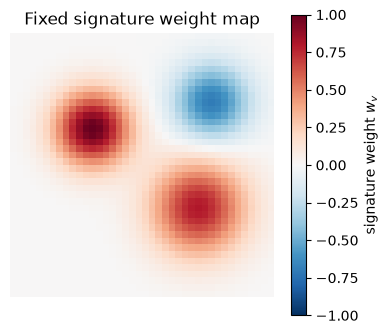

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import roc_curve, roc_auc_score

side = 40                          # image grid: side x side "voxels" (1,600 total)
yy, xx = np.mgrid[0:side, 0:side]

def blob(cx, cy, sd):
    """A smooth Gaussian 'region' on the image grid."""
    return np.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2 * sd ** 2))

# The signature: FIXED weights, treated as if trained on prior studies
W = 1.0 * blob(12, 14, 4) + 0.8 * blob(28, 26, 5) - 0.7 * blob(30, 10, 4)
w = W.ravel()                      # vectorized weights, one per "voxel"
n_vox = w.size

plt.figure(figsize=(4, 3.5))
plt.imshow(W, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(label="signature weight $w_v$")
plt.title("Fixed signature weight map")
plt.axis("off")
plt.tight_layout()
plt.show()

## 2. Simulate new test subjects' condition images

Thirty new subjects, three conditions each:

- **pain** — the target condition; expresses the signature strongly (amplitude ≈ 1.0, varying across subjects)
- **sound** — an arousing but non-painful control; expresses the signature weakly (a *confusable* condition, in the spirit of Figure 40.2)
- **warmth** — a neutral control; no signature expression

Each subject also gets a **baseline (global) offset** shared across their conditions, plus independent voxel noise — the kinds of nuisance variation real condition images carry.

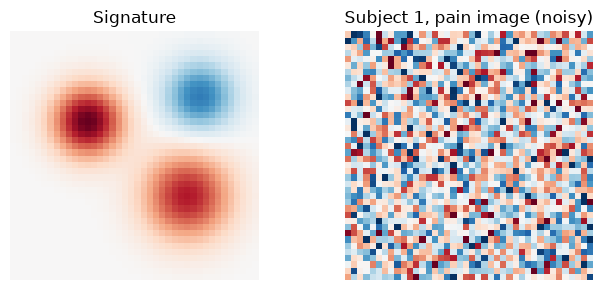

In [2]:
rng = np.random.default_rng(2026)  # seed, for reproducibility
n_sub = 30                                # number of new test subjects

amp_pain  = rng.normal(1.0, 0.4, n_sub)   # target: strong expression
amp_sound = rng.normal(0.3, 0.2, n_sub)   # confusable control: weak expression
amp_warm  = np.zeros(n_sub)               # neutral control: none

offset   = rng.normal(0, 0.3, n_sub)      # subject baseline (global) differences
noise_sd = 4.0                            # voxel noise

def make_condition_images(amp):
    return (amp[:, None] * w + offset[:, None]
            + noise_sd * rng.standard_normal((n_sub, n_vox)))

img_pain  = make_condition_images(amp_pain)    # subjects x voxels
img_sound = make_condition_images(amp_sound)
img_warm  = make_condition_images(amp_warm)

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].imshow(W, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_title("Signature")
axes[1].imshow(img_pain[0].reshape(side, side), cmap="RdBu_r", vmin=-8, vmax=8)
axes[1].set_title("Subject 1, pain image (noisy)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

Notice that the signature is invisible to the eye in any single noisy image. The whole point of a multivariate pattern is that a weighted sum across thousands of voxels can recover a signal no single voxel shows reliably.

## 3. Pattern responses: the dot product

The **pattern response** for an image $\mathbf{x}$ is

::::{div}
:class: eq-tip
$$
r = \mathbf{w}^\top \mathbf{x} = \sum_{v=1}^{V} w_v\, x_v
$$
:::{div}
:class: eq-tip-text
r — pattern response (signature score) · w — fixed signature weights (voxels × 1) · x — brain image as a vector (voxels × 1) · wᵥ, xᵥ — weight and image value at voxel v · V — number of voxels
:::
::::
:::{div}
:class: eq-where
*where* $r$ *is the pattern response (the signature's score for the image),* $\mathbf{w}$ *the fixed vector of signature weights (one per voxel),* $\mathbf{x}$ *the brain image arranged as a vector,* $w_v$ *and* $x_v$ *their values at voxel* $v$*, and* $V$ *the number of voxels.*
:::

a weighted average of image values with weights fixed by the signature. (With CANlab tools this is `apply_mask(data_obj, signature, 'pattern_expression', 'ignore_missing')`; with nilearn you would mask both images to a common space and take the dot product, exactly as below.)

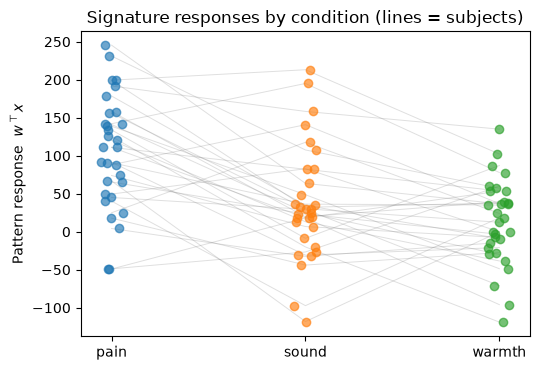

Mean responses: {'pain': 104.8, 'sound': 37.4, 'warmth': 12.8}


In [3]:
resp = {"pain": img_pain @ w, "sound": img_sound @ w, "warmth": img_warm @ w}

plt.figure(figsize=(5.5, 3.8))
for s in range(n_sub):   # connect each subject's conditions
    plt.plot([0, 1, 2], [resp["pain"][s], resp["sound"][s], resp["warmth"][s]],
             "-", color="gray", alpha=0.25, lw=0.7)
for i, (name, r) in enumerate(resp.items()):
    plt.plot(np.full(n_sub, i) + rng.uniform(-.06, .06, n_sub), r, "o", alpha=.65,
             label=name)
plt.xticks([0, 1, 2], list(resp))
plt.ylabel(r"Pattern response  $w^\top x$")
plt.title("Signature responses by condition (lines = subjects)")
plt.tight_layout()
plt.show()

print("Mean responses:", {k: round(float(v.mean()), 1) for k, v in resp.items()})

The response is graded — largest for pain, intermediate for the arousing sound, near zero for warmth — mirroring how a well-designed signature should track its target construct across a dynamic range rather than just separating two arbitrary classes.

## 4. Paired forced-choice accuracy

The natural within-person test: for each subject, *which condition produced the larger pattern response?* Because both responses come from the same person, baseline (offset) differences between subjects cancel. We test accuracy against chance (50%) with a binomial test.

In [4]:
def forced_choice(a, b):
    k = int(np.sum(a > b))
    acc = k / n_sub
    p = stats.binomtest(k, n_sub, 0.5).pvalue
    return acc, p

for c1, c2 in [("pain", "warmth"), ("pain", "sound"), ("sound", "warmth")]:
    acc, p = forced_choice(resp[c1], resp[c2])
    print(f"{c1:>6} vs {c2:<7}  forced-choice accuracy = {acc:.2f}  (binomial p = {p:.2g})")

  pain vs warmth   forced-choice accuracy = 0.97  (binomial p = 5.8e-08)
  pain vs sound    forced-choice accuracy = 0.77  (binomial p = 0.0052)
 sound vs warmth   forced-choice accuracy = 0.67  (binomial p = 0.099)


Pain vs. warmth discrimination is excellent; pain vs. the confusable sound condition is harder — that gap between the two comparisons is a measure of the signature's **specificity**, and it is only visible because the test set includes a confusable control condition (sample design at work).

## 5. ROC curves, sensitivity, and specificity

For *single-interval* classification — deciding from one image alone, with one threshold applied to everyone — we trace the ROC curve, compute the area under it (AUC), and read off sensitivity and specificity at the best balanced threshold (Youden's J).

pain vs warmth   AUC = 0.84 | at best threshold: sensitivity = 0.73, specificity = 0.87
pain vs sound    AUC = 0.75 | at best threshold: sensitivity = 0.83, specificity = 0.67


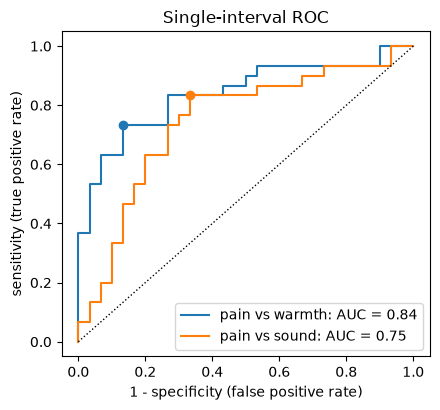

In [5]:
plt.figure(figsize=(4.5, 4.2))
for ctrl, color in [("warmth", "tab:blue"), ("sound", "tab:orange")]:
    y = np.r_[np.ones(n_sub), np.zeros(n_sub)]
    v = np.r_[resp["pain"], resp[ctrl]]
    fpr, tpr, thr = roc_curve(y, v)
    auc = roc_auc_score(y, v)
    j = np.argmax(tpr - fpr)                 # Youden's J: best balanced threshold
    plt.plot(fpr, tpr, color=color, label=f"pain vs {ctrl}: AUC = {auc:.2f}")
    plt.plot(fpr[j], tpr[j], "o", color=color)
    print(f"pain vs {ctrl:<7}  AUC = {auc:.2f} | at best threshold: "
          f"sensitivity = {tpr[j]:.2f}, specificity = {1 - fpr[j]:.2f}")

plt.plot([0, 1], [0, 1], "k:", lw=1)
plt.xlabel("1 - specificity (false positive rate)")
plt.ylabel("sensitivity (true positive rate)")
plt.title("Single-interval ROC")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Compare the single-interval sensitivity/specificity with the forced-choice accuracies above: forced choice does better, because between-subject baseline variance — which a single threshold must fight through — cancels in the paired comparison. Published signatures (e.g., the Neurologic Pain Signature) show exactly this pattern: forced-choice accuracy is typically the highest-powered test.

## 6. Metric choice and calibration across scanners

The dot product is not the only way to compare an image with a pattern:

- **dot product** $\mathbf{w}^\top\mathbf{x}$ — keeps the image's units; sensitive to scanner gain *and* offset
- **cosine similarity** $\mathbf{w}^\top\mathbf{x} / (\lVert\mathbf{w}\rVert \lVert\mathbf{x}\rVert)$ — invariant to multiplicative gain, still sensitive to additive offsets
- **correlation** — cosine similarity after mean-centering both vectors; invariant to gain *and* uniform offset

Suppose the same subjects' pain images had come from "Scanner B", which scales signal by 1.8× and adds a uniform offset. Watch what happens to each metric.

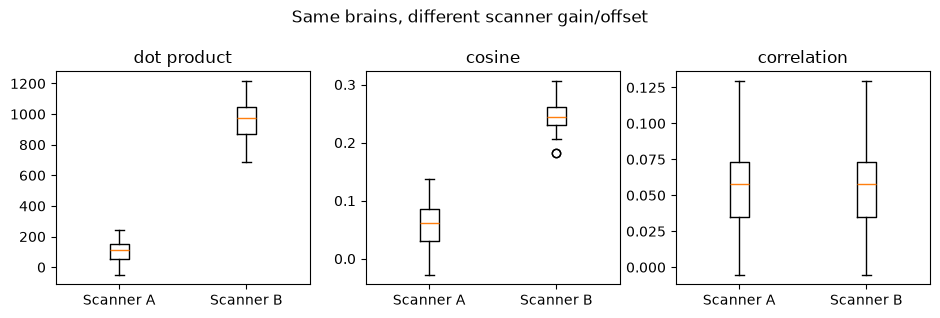

In [6]:
def pattern_metrics(X, w):
    dot = X @ w
    cos = dot / (np.linalg.norm(X, axis=1) * np.linalg.norm(w))
    Xc = X - X.mean(axis=1, keepdims=True)
    wc = w - w.mean()
    corr = (Xc @ wc) / (np.linalg.norm(Xc, axis=1) * np.linalg.norm(wc))
    return {"dot product": dot, "cosine": cos, "correlation": corr}

gain, shift = 1.8, 5.0                        # Scanner B: multiplicative gain, additive offset
img_pain_B = gain * img_pain + shift          # same brains, different scanner

mA = pattern_metrics(img_pain, w)
mB = pattern_metrics(img_pain_B, w)

fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.2))
for ax, name in zip(axes, mA):
    ax.boxplot([mA[name], mB[name]])
    ax.set_xticklabels(["Scanner A", "Scanner B"])
    ax.set_title(name)
fig.suptitle("Same brains, different scanner gain/offset")
plt.tight_layout()
plt.show()

In [7]:
# Within-scanner, within-person comparisons survive the transformation:
img_warm_B = gain * img_warm + shift
acc_A = np.mean(resp["pain"] > resp["warmth"])
acc_B = np.mean(img_pain_B @ w > img_warm_B @ w)
print(f"Forced-choice accuracy (pain vs warmth), Scanner A: {acc_A:.2f}")
print(f"Forced-choice accuracy (pain vs warmth), Scanner B: {acc_B:.2f}")

Forced-choice accuracy (pain vs warmth), Scanner A: 0.97
Forced-choice accuracy (pain vs warmth), Scanner B: 0.97


The raw dot product shifts dramatically between scanners — pooling it across sites without harmonization would be misleading. Cosine similarity removes the gain but not the offset; correlation is robust to both. And the paired forced-choice accuracy is *identical* on both scanners, because within-person comparisons are invariant to any transformation applied equally to a subject's conditions.

## Summary

- A population-level signature is a **fixed weight map**; its response to a new image is the **dot product** $\mathbf{w}^\top\mathbf{x}$ — a pattern-weighted generalization of the ROI average. It is never re-fit to test data.
- Responses should be **graded** across conditions; testing against *confusable* controls (not just neutral ones) quantifies **specificity**.
- **Paired forced-choice** tests are high-powered because subject baselines cancel; single-interval **ROC/sensitivity/specificity** characterize threshold-based classification.
- Metric choice matters for **calibration across scanners**: dot products are scale- and offset-sensitive, cosine similarity is gain-invariant, correlation is gain- and offset-invariant — and within-person comparisons are the most robust of all.

Next, Chapter 41 takes up what it means for such a signature to become a validated **neuromarker**.